# Steam Review Sentiment Analysis with Deep Learning

In [1]:
import re
import string
import pickle
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px

from wordcloud import WordCloud

import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import torch.optim as optim

In [2]:
nltk.download("stopwords")
nltk.download("punkt")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\samym\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\samym\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs")

(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "metrics").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "predictions").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "explainability").mkdir(parents=True, exist_ok=True)

Path("../models").mkdir(exist_ok=True)

In [4]:
SEED = 42

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [5]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA Graphics Device


In [6]:
DATA_PATH = "../data/dataset.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Shape : (6417106, 5)


,app_id,app_name,review_text,review_score,review_votes
0,10,Counter-Strike,Ruined my life.,1,0
1,10,Counter-Strike,This will be more of a ''my experience with th...,1,1
2,10,Counter-Strike,This game saved my virginity.,1,0
3,10,Counter-Strike,• Do you like original games? • Do you like ga...,1,0
4,10,Counter-Strike,"Easy to learn, hard to master.",1,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6417106 entries, 0 to 6417105
Data columns (total 5 columns):
 #   Column        Dtype
---  ------        -----
 0   app_id        int64
 1   app_name      str  
 2   review_text   str  
 3   review_score  int64
 4   review_votes  int64
dtypes: int64(3), str(2)
memory usage: 244.8 MB


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
app_id,6417106.0,NaN,NaN,NaN,227469.499959,126045.06578,10.0,201810.0,239160.0,305620.0,565340.0
app_name,6233872,9363,PAYDAY 2,88973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_text,6409801,4473473,Early Access Review,1013351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_score,6417106.0,NaN,NaN,NaN,0.639499,0.768792,-1.0,1.0,1.0,1.0,1.0
review_votes,6417106.0,NaN,NaN,NaN,0.147245,0.35435,0.0,0.0,0.0,0.0,1.0


In [9]:
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("Missing Values")
)

missing_values

,Missing Values
app_name,183234
review_text,7305
app_id,0
review_score,0
review_votes,0


In [10]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 1796102


In [11]:
df.columns.tolist()

['app_id', 'app_name', 'review_text', 'review_score', 'review_votes']

In [12]:
review_distribution = (
    df["review_score"]
    .value_counts()
    .sort_index()
)

review_distribution

review_score
-1    1156686
 1    5260420
Name: count, dtype: int64

In [13]:
fig = px.bar(

    x=["Negative", "Positive"],

    y=[
        review_distribution[-1],
        review_distribution[1]
    ],

    labels={
        "x":"Review Sentiment",
        "y":"Number of Reviews"
    },

    title="Steam Review Sentiment Distribution"

)

fig.write_image("../outputs/figures/dataset_distribution.png")

fig.show()

In [14]:
df = df[[
    "review_text",
    "review_score"
]]

df.head()

,review_text,review_score
0,Ruined my life.,1
1,This will be more of a ''my experience with th...,1
2,This game saved my virginity.,1
3,• Do you like original games? • Do you like ga...,1
4,"Easy to learn, hard to master.",1


In [15]:
df = df.dropna()

print(df.shape)

(6409801, 2)


In [16]:
df["review_score"] = (
    df["review_score"]
    .replace({
        -1:0,
         1:1
    })
)

df.head()

,review_text,review_score
0,Ruined my life.,1
1,This will be more of a ''my experience with th...,1
2,This game saved my virginity.,1
3,• Do you like original games? • Do you like ga...,1
4,"Easy to learn, hard to master.",1


In [17]:
SAMPLE_SIZE = 100_000

positive_reviews = (
    df[df["review_score"] == 1]
    .sample(n=SAMPLE_SIZE // 2, random_state=42)
)

negative_reviews = (
    df[df["review_score"] == 0]
    .sample(n=SAMPLE_SIZE // 2, random_state=42)
)

df = pd.concat(
    [positive_reviews, negative_reviews],
    ignore_index=True
)

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(df.shape)

df.head()

(100000, 2)


,review_text,review_score
0,A fairly regreattable experience. There are in...,0
1,Early Access Review,0
2,"One of my favorite games. Not much of a story,...",1
3,"Bad bugs. Pirates ships do not finish sinking,...",0
4,Stay away until they fix all the hacking which...,0


In [18]:
distribution = (
    df["review_score"]
      .value_counts()
      .rename(index={
          0: "Negative",
          1: "Positive"
      })
)

distribution

review_score
Negative    50000
Positive    50000
Name: count, dtype: int64

## EDA

In [19]:
df["review_length"] = (
    df["review_text"]
    .astype(str)
    .apply(len)
)

df["word_count"] = (
    df["review_text"]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

df[
    ["review_length", "word_count"]
].describe()

,review_length,word_count
count,100000.000000,100000.000000
mean,336.600800,61.366510
std,648.928859,116.987134
min,1.000000,0.000000
25%,30.000000,6.000000
50%,115.000000,21.000000
75%,351.000000,65.000000
max,8364.000000,1925.000000


In [20]:
fig = px.histogram(

    df,

    x="word_count",

    nbins=80,

    title="Distribution of Review Lengths",

    labels={
        "word_count":"Number of Words"
    }

)

fig.write_image(
    "../outputs/figures/review_length.png"
)

fig.show()

In [21]:
fig = px.scatter(

    df.sample(5000, random_state=42),

    x="word_count",

    y="review_length",

    opacity=0.5,

    title="Character Count vs Word Count"

)

fig.write_image(
    "../outputs/figures/review_length_scatter.png"
)

fig.show()

In [22]:
df.nlargest(
    5,
    "word_count"
)[
    ["word_count", "review_text"]
]

,word_count,review_text
31542,1925,DONT LET ME GET INTO MY ZONE DONT LET ME GET I...
77010,1563,"Look, I was gonna go easy on you and not to hu..."
18301,1549,This game is not bad. I can understand why peo...
61869,1497,I want to make this review a meaningful one be...
81951,1489,"My first review, I don't do reviews but this g..."


In [23]:
df.nsmallest(
    10,
    "word_count"
)[
    ["word_count", "review_text"]
]

,word_count,review_text
17204,0,
279,1,.
449,1,♥♥♥♥
556,1,♥♥♥♥
657,1,.
675,1,#teamfortress3
725,1,!
764,1,10/10
839,1,Trash
879,1,Boring


In [24]:
review_stats = pd.DataFrame({

    "Statistic":[
        "Average Characters",
        "Average Words",
        "Median Words",
        "Maximum Words",
        "Minimum Words"
    ],

    "Value":[
        round(df["review_length"].mean(),2),
        round(df["word_count"].mean(),2),
        int(df["word_count"].median()),
        int(df["word_count"].max()),
        int(df["word_count"].min())
    ]

})

review_stats

,Statistic,Value
0,Average Characters,336.60
1,Average Words,61.37
2,Median Words,21.00
3,Maximum Words,1925.00
4,Minimum Words,0.00


In [25]:
review_stats.to_csv(
    "../outputs/metrics/review_length_statistics.csv",
    index=False
)

## text cleaning

In [26]:
df["review_text"].sample(
    5,
    random_state=42
)

75721    Simply Incredible. I enjoy this game a lot in ...
80184    I had to redo this review because after playin...
19864                          This game is not an 4x game
76699                                  Early Access Review
92991    this game will EXTRAORDINARILY GOOD if they do...
Name: review_text, dtype: str

In [27]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords
    words = [
        word
        for word in text.split()
        if word not in stop_words
    ]

    return " ".join(words)

In [28]:
df["clean_review"] = (
    df["review_text"]
    .apply(clean_text)
)

df[
    ["review_text", "clean_review"]
].head()

,review_text,clean_review
0,A fairly regreattable experience. There are in...,fairly regreattable experience incentives driv...
1,Early Access Review,early access review
2,"One of my favorite games. Not much of a story,...",one favorite games much story chilling unique ...
3,"Bad bugs. Pirates ships do not finish sinking,...",bad bugs pirates ships finish sinking never co...
4,Stay away until they fix all the hacking which...,stay away fix hacking probably wont happen sin...


In [29]:
comparison = df.sample(
    5,
    random_state=42
)[
    [
        "review_text",
        "clean_review"
    ]
]

comparison

,review_text,clean_review
75721,Simply Incredible. I enjoy this game a lot in ...,simply incredible enjoy game lot short bursts ...
80184,I had to redo this review because after playin...,redo review playing long time posting say game...
19864,This game is not an 4x game,game 4x game
76699,Early Access Review,early access review
92991,this game will EXTRAORDINARILY GOOD if they do...,game extraordinarily good dont bad moderator a...


In [30]:
comparison.to_csv(
    "../outputs/metrics/text_cleaning_examples.csv",
    index=False
)

## Tokenization

In [31]:
df["tokens"] = (
    df["clean_review"]
    .str.split()
)

df[
    ["clean_review", "tokens"]
].head()

,clean_review,tokens
0,fairly regreattable experience incentives driv...,"[fairly, regreattable, experience, incentives,..."
1,early access review,"[early, access, review]"
2,one favorite games much story chilling unique ...,"[one, favorite, games, much, story, chilling, ..."
3,bad bugs pirates ships finish sinking never co...,"[bad, bugs, pirates, ships, finish, sinking, n..."
4,stay away fix hacking probably wont happen sin...,"[stay, away, fix, hacking, probably, wont, hap..."


In [32]:
df["tokens"].sample(
    5,
    random_state=42
)

75721    [simply, incredible, enjoy, game, lot, short, ...
80184    [redo, review, playing, long, time, posting, s...
19864                                     [game, 4x, game]
76699                              [early, access, review]
92991    [game, extraordinarily, good, dont, bad, moder...
Name: tokens, dtype: object

In [33]:
df["token_count"] = (
    df["tokens"]
    .apply(len)
)

df["token_count"].describe()

count    100000.000000
mean         32.553150
std          60.638377
min           0.000000
25%           3.000000
50%          12.000000
75%          34.000000
max        1281.000000
Name: token_count, dtype: float64

In [34]:
fig = px.histogram(

    df,

    x="token_count",

    nbins=80,

    title="Distribution of Token Counts"

)

fig.write_image(
    "../outputs/figures/token_count_distribution.png"
)

fig.show()

In [35]:
compression = pd.DataFrame({

    "Metric":[
        "Average Words Before Cleaning",
        "Average Tokens After Cleaning",
        "Average Reduction"
    ],

    "Value":[

        round(df["word_count"].mean(),2),

        round(df["token_count"].mean(),2),

        round(
            df["word_count"].mean()
            -
            df["token_count"].mean(),
            2
        )

    ]

})

compression

,Metric,Value
0,Average Words Before Cleaning,61.37
1,Average Tokens After Cleaning,32.55
2,Average Reduction,28.81


In [36]:
compression.to_csv(
    "../outputs/metrics/token_statistics.csv",
    index=False
)

## Vocabulary

In [37]:
from collections import Counter

word_counter = Counter()

for tokens in df["tokens"]:

    word_counter.update(tokens)

print(f"Unique Words : {len(word_counter):,}")

Unique Words : 103,560


In [38]:
top_words = pd.DataFrame(

    word_counter.most_common(20),

    columns=[
        "Word",
        "Frequency"
    ]

)

top_words

,Word,Frequency
0,game,139100
1,like,30225
2,get,23411
3,play,23288
4,review,21094
5,one,20422
6,good,19858
7,really,18462
8,early,18216
9,access,17815


In [39]:
fig = px.bar(

    top_words,

    x="Word",

    y="Frequency",

    title="Top 20 Most Frequent Words"

)

fig.write_image(
    "../outputs/figures/word_frequency.png"
)

fig.show()

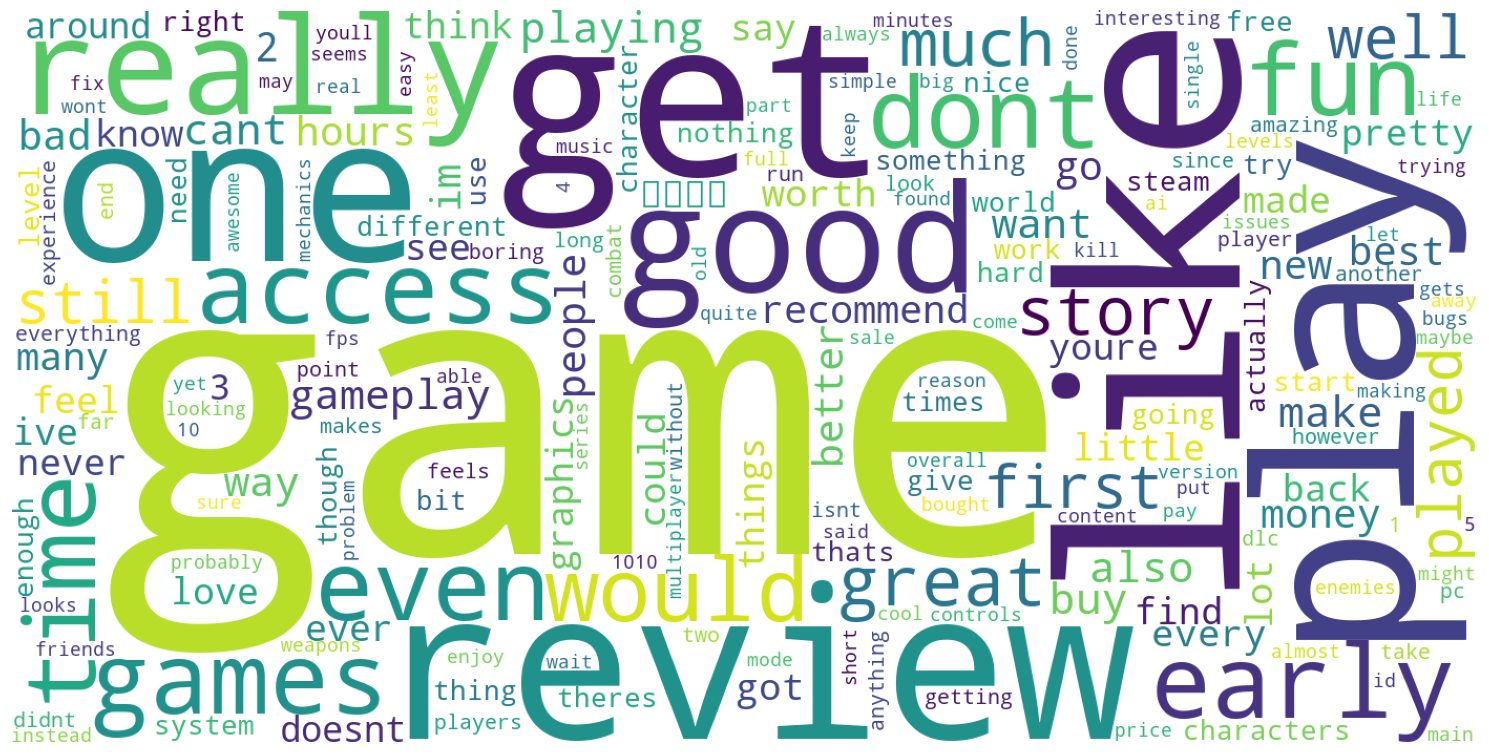

In [40]:
wordcloud = WordCloud(

    width=1400,
    height=700,

    background_color="white"

).generate_from_frequencies(word_counter)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/word_cloud.png",
    dpi=300
)

plt.show()

In [41]:
VOCAB_SIZE = 20_000
vocabulary = {

    "<PAD>":0,

    "<UNK>":1

}

for word, _ in word_counter.most_common(VOCAB_SIZE - 2):

    vocabulary[word] = len(vocabulary)

print(f"Vocabulary Size : {len(vocabulary):,}")

Vocabulary Size : 20,000


In [42]:
with open(
    "../models/vocabulary.pkl",
    "wb"
) as f:

    pickle.dump(
        vocabulary,
        f
    )

In [43]:
list(vocabulary.items())[:20]

[('<PAD>', 0),
 ('<UNK>', 1),
 ('game', 2),
 ('like', 3),
 ('get', 4),
 ('play', 5),
 ('review', 6),
 ('one', 7),
 ('good', 8),
 ('really', 9),
 ('early', 10),
 ('access', 11),
 ('games', 12),
 ('dont', 13),
 ('fun', 14),
 ('time', 15),
 ('even', 16),
 ('would', 17),
 ('great', 18),
 ('story', 19)]

## Encoding

In [44]:
MAX_LENGTH = 100

def encode_review(tokens):

    encoded = []

    for word in tokens:

        encoded.append(
            vocabulary.get(
                word,
                vocabulary["<UNK>"]
            )
        )

    return encoded

In [45]:
df["encoded_review"] = (
    df["tokens"]
    .apply(encode_review)
)

df[
    [
        "tokens",
        "encoded_review"
    ]
].head()

,tokens,encoded_review
0,"[fairly, regreattable, experience, incentives,...","[596, 1, 112, 17649, 845, 231, 2, 77, 161, 92,..."
1,"[early, access, review]","[10, 11, 6]"
2,"[one, favorite, games, much, story, chilling, ...","[7, 503, 12, 20, 19, 8231, 300, 606, 1266, 35,..."
3,"[bad, bugs, pirates, ships, finish, sinking, n...","[34, 167, 2426, 628, 408, 6463, 66, 231, 147, ..."
4,"[stay, away, fix, hacking, probably, wont, hap...","[641, 196, 190, 1791, 156, 172, 675, 102, 63, ..."


In [46]:
MAX_LENGTH = 100
def pad_sequence(sequence):

    if len(sequence) >= MAX_LENGTH:

        return sequence[:MAX_LENGTH]

    return sequence + [

        vocabulary["<PAD>"]

    ] * (MAX_LENGTH - len(sequence))

In [47]:
df["input_ids"] = (
    df["encoded_review"]
    .apply(pad_sequence)
)

df[
    [
        "encoded_review",
        "input_ids"
    ]
].head()

,encoded_review,input_ids
0,"[596, 1, 112, 17649, 845, 231, 2, 77, 161, 92,...","[596, 1, 112, 17649, 845, 231, 2, 77, 161, 92,..."
1,"[10, 11, 6]","[10, 11, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0..."
2,"[7, 503, 12, 20, 19, 8231, 300, 606, 1266, 35,...","[7, 503, 12, 20, 19, 8231, 300, 606, 1266, 35,..."
3,"[34, 167, 2426, 628, 408, 6463, 66, 231, 147, ...","[34, 167, 2426, 628, 408, 6463, 66, 231, 147, ..."
4,"[641, 196, 190, 1791, 156, 172, 675, 102, 63, ...","[641, 196, 190, 1791, 156, 172, 675, 102, 63, ..."


In [48]:
df["sequence_length"] = (
    df["input_ids"]
    .apply(len)
)

df["sequence_length"].value_counts()

sequence_length
100    100000
Name: count, dtype: int64

In [49]:
sample = df.sample(
    1,
    random_state=42
).iloc[0]

print("Original Review:\n")
print(sample["review_text"])

print("\nClean Review:\n")
print(sample["clean_review"])

print("\nTokens:\n")
print(sample["tokens"][:20])

print("\nEncoded:\n")
print(sample["encoded_review"][:20])

print("\nPadded:\n")
print(sample["input_ids"][:20])

Original Review:

Simply Incredible. I enjoy this game a lot in short bursts. 10/10

Clean Review:

simply incredible enjoy game lot short bursts 1010

Tokens:

['simply', 'incredible', 'enjoy', 'game', 'lot', 'short', 'bursts', '1010']

Encoded:

[242, 1029, 141, 2, 46, 128, 6152, 140]

Padded:

[242, 1029, 141, 2, 46, 128, 6152, 140, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [50]:
transformation = pd.DataFrame({

    "Stage":[
        "Original",
        "Clean",
        "Tokens",
        "Encoded",
        "Padded"
    ],

    "Output":[
        sample["review_text"],
        sample["clean_review"],
        str(sample["tokens"]),
        str(sample["encoded_review"]),
        str(sample["input_ids"])
    ]

})

transformation.to_csv(
    "../outputs/metrics/text_transformation_pipeline.csv",
    index=False
)

## PyTorch

In [51]:
X = np.array(df["input_ids"].tolist())

y = df["review_score"].values

print("Feature Shape :", X.shape)
print("Label Shape   :", y.shape)

Feature Shape : (100000, 100)
Label Shape   : (100000,)


In [52]:
indices = np.arange(len(df))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(

    X,
    y,
    indices,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [53]:
X_train, X_validation, y_train, y_validation, idx_train, idx_validation = train_test_split(

    X_train,
    y_train,
    idx_train,

    test_size=0.20,

    random_state=42,

    stratify=y_train

)

In [54]:
X_train = torch.tensor(
    X_train,
    dtype=torch.long
)

X_validation = torch.tensor(
    X_validation,
    dtype=torch.long
)

X_test = torch.tensor(
    X_test,
    dtype=torch.long
)

y_train = torch.tensor(
    y_train,
    dtype=torch.float32
).unsqueeze(1)

y_validation = torch.tensor(
    y_validation,
    dtype=torch.float32
).unsqueeze(1)

y_test = torch.tensor(
    y_test,
    dtype=torch.float32
).unsqueeze(1)

In [55]:
# tensor datasets
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(
    X_train,
    y_train
)

validation_dataset = TensorDataset(
    X_validation,
    y_validation
)

test_dataset = TensorDataset(
    X_test,
    y_test
)

In [56]:
# dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True

)

validation_loader = DataLoader(

    validation_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

In [57]:
features, labels = next(iter(train_loader))

print("Input Shape :", features.shape)
print("Label Shape :", labels.shape)

print("\nTensor Type :", features.dtype)

Input Shape : torch.Size([64, 100])
Label Shape : torch.Size([64, 1])

Tensor Type : torch.int64


In [58]:
dataset_summary = pd.DataFrame({

    "Property":[
        "Training Samples",
        "Validation Samples",
        "Testing Samples",
        "Vocabulary Size",
        "Maximum Sequence Length",
        "Batch Size"
    ],

    "Value":[
        len(train_dataset),
        len(validation_dataset),
        len(test_dataset),
        len(vocabulary),
        MAX_LENGTH,
        BATCH_SIZE
    ]

})

dataset_summary

,Property,Value
0,Training Samples,64000
1,Validation Samples,16000
2,Testing Samples,20000
3,Vocabulary Size,20000
4,Maximum Sequence Length,100
5,Batch Size,64


In [59]:
dataset_summary.to_csv(
    "../outputs/metrics/dataset_summary.csv",
    index=False
)

## Embedding-based Sentiment Classifier

### Word Embeddings

In [60]:
EMBEDDING_DIM = 128

HIDDEN_DIM = 128

DROPOUT = 0.5

LEARNING_RATE = 0.001

EPOCHS = 20

PATIENCE = 5

In [61]:
training_config = pd.DataFrame({

    "Hyperparameter":[
        "Vocabulary Size",
        "Embedding Dimension",
        "Hidden Dimension",
        "Sequence Length",
        "Batch Size",
        "Learning Rate",
        "Epochs",
        "Dropout",
        "Optimizer",
        "Loss Function"
    ],

    "Value":[
        len(vocabulary),
        EMBEDDING_DIM,
        HIDDEN_DIM,
        MAX_LENGTH,
        BATCH_SIZE,
        LEARNING_RATE,
        EPOCHS,
        DROPOUT,
        "Adam",
        "BCEWithLogitsLoss"
    ]

})

training_config

,Hyperparameter,Value
0,Vocabulary Size,20000
1,Embedding Dimension,128
2,Hidden Dimension,128
3,Sequence Length,100
4,Batch Size,64
5,Learning Rate,0.001
6,Epochs,20
7,Dropout,0.5
8,Optimizer,Adam
9,Loss Function,BCEWithLogitsLoss


In [62]:
training_config.to_csv(
    "../outputs/metrics/training_configuration.csv",
    index=False
)

In [63]:
class SentimentClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(

            num_embeddings=len(vocabulary),

            embedding_dim=EMBEDDING_DIM,

            padding_idx=vocabulary["<PAD>"]

        )

        self.classifier = nn.Sequential(

            nn.Linear(
                EMBEDDING_DIM,
                HIDDEN_DIM
            ),

            nn.ReLU(),

            nn.Dropout(DROPOUT),

            nn.Linear(
                HIDDEN_DIM,
                1
            )

        )

    def forward(self, x):

        x = self.embedding(x)

        x = x.mean(dim=1)

        x = self.classifier(x)

        return x

In [64]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SentimentClassifier().to(DEVICE)

print(model)

SentimentClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [65]:
total_params = sum(

    p.numel()

    for p in model.parameters()

)

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

parameter_summary = pd.DataFrame({

    "Metric":[
        "Total Parameters",
        "Trainable Parameters"
    ],

    "Value":[
        total_params,
        trainable_params
    ]

})

parameter_summary

,Metric,Value
0,Total Parameters,2576641
1,Trainable Parameters,2576641


In [66]:
parameter_summary.to_csv(
    "../outputs/metrics/model_parameters.csv",
    index=False
)

In [67]:
features, labels = next(iter(train_loader))

features = features.to(DEVICE)

outputs = model(features)

print("Input Shape :", features.shape)
print("Output Shape:", outputs.shape)

Input Shape : torch.Size([64, 100])
Output Shape: torch.Size([64, 1])


### Training Preparation

In [68]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=LEARNING_RATE

)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=2

)

In [69]:
def calculate_accuracy(outputs, labels):

    probabilities = torch.sigmoid(outputs)

    predictions = (probabilities >= 0.5).float()

    accuracy = (

        predictions == labels

    ).float().mean()

    return accuracy.item()

In [70]:
history = {

    "train_loss": [],

    "validation_loss": [],

    "train_accuracy": [],

    "validation_accuracy": [],

    "learning_rate": []

}

best_validation_loss = float("inf")

early_stop_counter = 0

In [71]:
from copy import deepcopy

best_model_state = None

for epoch in range(EPOCHS):

    # ===========================
    # Training
    # ===========================

    model.train()

    train_loss = 0.0
    train_accuracy = 0.0

    for reviews, labels in train_loader:

        reviews = reviews.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(reviews)

        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_norm=1.0

        )

        optimizer.step()

        train_loss += loss.item()

        train_accuracy += calculate_accuracy(

            outputs,

            labels

        )

    train_loss /= len(train_loader)
    train_accuracy /= len(train_loader)

    # ===========================
    # Validation
    # ===========================

    model.eval()

    validation_loss = 0.0
    validation_accuracy = 0.0

    with torch.no_grad():

        for reviews, labels in validation_loader:

            reviews = reviews.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(reviews)

            loss = criterion(outputs, labels)

            validation_loss += loss.item()

            validation_accuracy += calculate_accuracy(

                outputs,

                labels

            )

    validation_loss /= len(validation_loader)
    validation_accuracy /= len(validation_loader)

    scheduler.step(validation_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)

    history["train_accuracy"].append(train_accuracy)
    history["validation_accuracy"].append(validation_accuracy)

    history["learning_rate"].append(current_lr)

    print(

        f"Epoch [{epoch+1}/{EPOCHS}] | "

        f"Train Loss: {train_loss:.4f} | "

        f"Val Loss: {validation_loss:.4f} | "

        f"Train Acc: {train_accuracy:.4f} | "

        f"Val Acc: {validation_accuracy:.4f} | "

        f"LR: {current_lr:.6f}"

    )

    # ===========================
    # Save Best Model
    # ===========================

    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss

        best_model_state = deepcopy(

            model.state_dict()

        )

        torch.save(

            model.state_dict(),

            "../models/sentiment_model.pth"

        )

        early_stop_counter = 0

    else:

        early_stop_counter += 1

    if early_stop_counter >= PATIENCE:

        print("\nEarly stopping triggered.")

        break

Epoch [1/20] | Train Loss: 0.5397 | Val Loss: 0.4514 | Train Acc: 0.7162 | Val Acc: 0.7795 | LR: 0.001000
Epoch [2/20] | Train Loss: 0.4200 | Val Loss: 0.4313 | Train Acc: 0.7894 | Val Acc: 0.7908 | LR: 0.001000
Epoch [3/20] | Train Loss: 0.3831 | Val Loss: 0.4349 | Train Acc: 0.8097 | Val Acc: 0.7923 | LR: 0.001000
Epoch [4/20] | Train Loss: 0.3597 | Val Loss: 0.4455 | Train Acc: 0.8214 | Val Acc: 0.7901 | LR: 0.001000
Epoch [5/20] | Train Loss: 0.3401 | Val Loss: 0.4633 | Train Acc: 0.8297 | Val Acc: 0.7900 | LR: 0.000500
Epoch [6/20] | Train Loss: 0.3194 | Val Loss: 0.4841 | Train Acc: 0.8408 | Val Acc: 0.7879 | LR: 0.000500
Epoch [7/20] | Train Loss: 0.3099 | Val Loss: 0.5035 | Train Acc: 0.8442 | Val Acc: 0.7861 | LR: 0.000500

Early stopping triggered.


In [72]:
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [73]:
history_df = pd.DataFrame(history)

history_df.to_csv(

    "../outputs/metrics/training_history.csv",

    index=False

)

history_df.head()

,train_loss,validation_loss,train_accuracy,validation_accuracy,learning_rate
0,0.539673,0.451356,0.716187,0.779500,0.0010
1,0.419985,0.431335,0.789422,0.790813,0.0010
2,0.383150,0.434936,0.809688,0.792312,0.0010
3,0.359694,0.445469,0.821422,0.790063,0.0010
4,0.340050,0.463326,0.829719,0.790000,0.0005


In [74]:
summary = pd.DataFrame({

    "Metric":[

        "Best Validation Loss",

        "Best Validation Accuracy",

        "Epochs Completed"

    ],

    "Value":[

        min(history["validation_loss"]),

        max(history["validation_accuracy"]),

        len(history["train_loss"])

    ]

})

summary

,Metric,Value
0,Best Validation Loss,0.431335
1,Best Validation Accuracy,0.792312
2,Epochs Completed,7.000000


In [75]:
summary.to_csv(

    "../outputs/metrics/training_summary.csv",

    index=False

)

In [76]:
import plotly.graph_objects as go

In [77]:
fig = go.Figure()

fig.add_trace(

    go.Scatter(

        y=history["train_loss"],

        mode="lines",

        name="Training Loss"

    )

)

fig.add_trace(

    go.Scatter(

        y=history["validation_loss"],

        mode="lines",

        name="Validation Loss"

    )

)

fig.update_layout(

    title="Training vs Validation Loss",

    xaxis_title="Epoch",

    yaxis_title="Loss"

)

fig.write_image(

    "../outputs/figures/training_loss.png"

)

fig.show()

In [78]:
fig = go.Figure()

fig.add_trace(

    go.Scatter(

        y=history["train_accuracy"],

        mode="lines",

        name="Training Accuracy"

    )

)

fig.add_trace(

    go.Scatter(

        y=history["validation_accuracy"],

        mode="lines",

        name="Validation Accuracy"

    )

)

fig.update_layout(

    title="Training vs Validation Accuracy",

    xaxis_title="Epoch",

    yaxis_title="Accuracy"

)

fig.write_image(

    "../outputs/figures/validation_accuracy.png"

)

fig.show()

In [79]:
fig = go.Figure()

fig.add_trace(

    go.Scatter(

        y=history["learning_rate"],

        mode="lines",

        name="Learning Rate"

    )

)

fig.update_layout(

    title="Learning Rate Schedule",

    xaxis_title="Epoch",

    yaxis_title="Learning Rate"

)

fig.write_image(

    "../outputs/figures/learning_rate.png"

)

fig.show()

## Model Evaluation

In [80]:
model.eval()

all_predictions = []
all_probabilities = []
all_labels = []

with torch.no_grad():

    for reviews, labels in test_loader:

        reviews = reviews.to(DEVICE)

        outputs = model(reviews)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.5).float()

        all_predictions.extend(
            predictions.cpu().numpy().flatten()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy().flatten()
        )

        all_labels.extend(
            labels.numpy().flatten()
        )

In [81]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions
)

recall = recall_score(
    all_labels,
    all_predictions
)

f1 = f1_score(
    all_labels,
    all_predictions
)

evaluation = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

evaluation

,Metric,Value
0,Accuracy,0.780500
1,Precision,0.826087
2,Recall,0.710600
3,F1 Score,0.764004


In [82]:
evaluation.to_csv(
    "../outputs/metrics/evaluation.csv",
    index=False
)

In [83]:
report = classification_report(

    all_labels,
    all_predictions,

    target_names=[
        "Negative",
        "Positive"
    ],

    output_dict=True

)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Negative,0.746096,0.8504,0.794841,10000.0000
Positive,0.826087,0.7106,0.764004,10000.0000
accuracy,0.780500,0.7805,0.780500,0.7805
macro avg,0.786091,0.7805,0.779422,20000.0000
weighted avg,0.786091,0.7805,0.779422,20000.0000


In [84]:
report_df.to_csv(
    "../outputs/metrics/classification_report.csv"
)

In [85]:
cm = confusion_matrix(

    all_labels,

    all_predictions
)

fig = px.imshow(

    cm,

    text_auto=True,

    color_continuous_scale="Blues",

    labels=dict(

        x="Predicted",

        y="Actual",

        color="Count"

    ),

    x=[
        "Negative",
        "Positive"
    ],

    y=[
        "Negative",
        "Positive"
    ],

    title="Confusion Matrix"

)

fig.write_image(
    "../outputs/figures/confusion_matrix.png"
)

fig.show()

In [86]:
from sklearn.metrics import (
    roc_curve,
    auc
)

fpr, tpr, _ = roc_curve(

    all_labels,

    all_probabilities

)

roc_auc = auc(
    fpr,
    tpr
)

fig = go.Figure()

fig.add_trace(

    go.Scatter(

        x=fpr,

        y=tpr,

        mode="lines",

        name=f"AUC = {roc_auc:.3f}"

    )

)

fig.add_trace(

    go.Scatter(

        x=[0,1],

        y=[0,1],

        mode="lines",

        line=dict(dash="dash"),

        name="Random"

    )

)

fig.update_layout(

    title="ROC Curve",

    xaxis_title="False Positive Rate",

    yaxis_title="True Positive Rate"

)

fig.write_image(
    "../outputs/figures/roc_curve.png"
)

fig.show()

In [87]:
fig = px.histogram(

    x=all_probabilities,

    nbins=30,

    title="Prediction Confidence Distribution",

    labels={

        "x":"Predicted Probability"

    }

)

fig.write_image(
    "../outputs/figures/prediction_confidence.png"
)

fig.show()

In [88]:
predictions_df = pd.DataFrame({

    "Actual":all_labels,

    "Prediction":all_predictions,

    "Confidence":all_probabilities

})

predictions_df.to_csv(

    "../outputs/predictions/predictions.csv",

    index=False

)

predictions_df.head()

,Actual,Prediction,Confidence
0,1.0,1.0,0.968683
1,0.0,0.0,0.002860
2,0.0,0.0,0.032557
3,1.0,0.0,0.116654
4,0.0,1.0,0.982129


In [89]:
prediction_results = pd.DataFrame({

    "review_text": df.iloc[idx_test]["review_text"].values,

    "clean_review": df.iloc[idx_test]["clean_review"].values,

    "Actual": all_labels,

    "Prediction": all_predictions,

    "Confidence": all_probabilities

})

misclassified = prediction_results[
    prediction_results["Actual"] != prediction_results["Prediction"]
]

misclassified.to_csv(

    "../outputs/predictions/misclassified_reviews.csv",

    index=False

)

misclassified.head()

,review_text,clean_review,Actual,Prediction,Confidence
3,Carmageddon is a vehicular combat 'racing' gam...,carmageddon vehicular combat racing game uk de...,1.0,0.0,0.116654
4,I enjoyed this game for about 3 our of the 4 h...,enjoyed game 3 4 hours took finish visuals phe...,0.0,1.0,0.982129
6,"Great Graphics! Awesome loadouts, but a lil bi...",great graphics awesome loadouts lil bit boring...,0.0,1.0,0.918382
11,Early Access Review,early access review,1.0,0.0,0.445087
13,got called a hacker first round i played (neve...,got called hacker first round played never che...,1.0,0.0,0.484712


## Explainability

In [92]:
from sklearn.decomposition import PCA

embedding_matrix = model.embedding.weight.detach().cpu().numpy()

embedding_matrix.shape

(20000, 128)

In [93]:
words = list(vocabulary.keys())[2:]

vectors = embedding_matrix[2:]

In [94]:
N_WORDS = 500

vectors = vectors[:N_WORDS]
words = words[:N_WORDS]

In [95]:
pca = PCA(n_components=2)

points = pca.fit_transform(vectors)

In [96]:
plot_df = pd.DataFrame({

    "x": points[:,0],

    "y": points[:,1],

    "word": words

})

plot_df.head()

,x,y,word
0,-0.813206,0.727035,game
1,1.756460,0.628918,like
2,-0.163113,-1.324976,get
3,1.494336,0.832369,play
4,-1.024337,0.575506,review


In [97]:
fig = px.scatter(

    plot_df,

    x="x",

    y="y",

    text="word",

    title="Word Embedding Space (PCA)"

)

fig.update_traces(textposition="top center")

fig.write_image(
    "../outputs/figures/embedding_visualization.png"
)

fig.show()

## Influential Tokens

In [98]:
def predict_probability(text):

    model.eval()

    cleaned = clean_text(text)

    encoded = encode_review(cleaned)

    padded = pad_sequence(encoded)

    tensor = torch.tensor(
        [padded],
        dtype=torch.long,
        device=DEVICE
    )

    with torch.no_grad():

        probability = torch.sigmoid(
            model(tensor)
        ).item()

    return probability

In [99]:
def explain_prediction(text):

    cleaned = clean_text(text)

    tokens = cleaned.split()

    base_probability = predict_probability(text)

    importance = []

    for i in range(len(tokens)):

        modified = tokens[:i] + tokens[i+1:]

        modified_text = " ".join(modified)

        new_probability = predict_probability(modified_text)

        importance.append({

            "Token": tokens[i],

            "Importance": abs(base_probability - new_probability)

        })

    explanation = pd.DataFrame(importance)

    explanation = explanation.sort_values(

        "Importance",

        ascending=False

    )

    return base_probability, explanation

In [100]:
sample_review = prediction_results.iloc[10]["review_text"]

probability, explanation = explain_prediction(sample_review)

print(sample_review)

print()

print(f"Predicted Positive Probability: {probability:.3f}")

explanation.head(15)

My mother told me if you have nothing good to say, don't say anything at all.  So heres my review.

Predicted Positive Probability: 0.589


,Token,Importance
5,dont,0.031499
9,review,0.025441
8,heres,0.023035
1,told,0.018687
2,nothing,0.015268
6,say,0.014859
4,say,0.014859
7,anything,0.011945
0,mother,0.006726
3,good,0.003904


In [101]:
fig = px.bar(

    explanation.head(15),

    x="Importance",

    y="Token",

    orientation="h",

    title="Most Influential Tokens"

)

fig.update_yaxes(

    categoryorder="total ascending"

)

fig.write_image(

    "../outputs/explainability/influential_tokens.png"

)

fig.show()